# IRON-SYNC — Preprocesamiento Dataset EMG
## Módulo A: Propulsión Muscular → TCN
**Universidad:** UMRPSFXCH | **Materia:** SIS-330 | **Estudiante:** Cervantes Torres Atzel Alan

Este cuadernillo prepara el dataset EMG sintético de IRON-SYNC para entrenamiento de modelos temporales (especialmente TCN). Se trabaja con tres clases fisiológicas de activación muscular: **BAJA**, **MEDIA** y **ALTA**.

Objetivos del notebook:
1. Cargar y validar integridad del dataset EMG.
2. Realizar análisis exploratorio de señales y amplitudes.
3. Extraer features clásicas de EMG (RMS, MAV, ZCR, WL, VAR).
4. Separar en train/val/test con estratificación (70/15/15).
5. Normalizar sin data leakage y guardar artefactos reproducibles.

### Estructura de columnas en CSV

| Columna | Tipo | Descripción |
|---|---|---|
| `time_ms` | float | Tiempo en milisegundos dentro de la ventana |
| `amplitude_mV` | float | Amplitud EMG en milivoltios |

### Parámetros del dataset EMG

| Parámetro | Valor |
|---|---|
| Frecuencia de muestreo nominal | 1000 Hz |
| Duración por muestra | 200 ms |
| Puntos por señal | 200 |
| Muestras por clase | 5000 |
| Total de muestras | 15000 |

##  Dependencias
Instala paquetes necesarios para ejecutar el notebook de principio a fin.

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn joblib tqdm

##  Imports y Configuración
En esta sección definimos rutas, constantes del proyecto, colores oficiales y semilla fija para reproducibilidad.

In [3]:
# ==============================
# Imports: stdlib
# ==============================
import random
import warnings
from pathlib import Path

# ==============================
# Imports: third-party
# ==============================
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ==============================
# Configuración global
# ==============================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

BASE_PATH = Path.cwd().resolve()
if not (BASE_PATH / 'dataset').exists() and (BASE_PATH.parent / 'dataset').exists():
    BASE_PATH = BASE_PATH.parent

DATASET_PATH = BASE_PATH / 'dataset' / 'EMG'
OUTPUT_PATH = BASE_PATH / 'cuadernillos' / 'preprocessed' / 'EMG'
FIGURES_PATH = BASE_PATH / 'cuadernillos' / 'figures'

CLASES = ['BAJA', 'MEDIA', 'ALTA']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

FS = 1000
N_PUNTOS = 200
MAX_POR_CLASE = None  # Cambiar a 500 para pruebas rápidas si fuera necesario

COLOR_MAP = {
    'BAJA': '#2196F3',
    'MEDIA': '#FF9800',
    'ALTA': '#F44336'
}

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print('Configuración cargada correctamente')
print(f'BASE_PATH      : {BASE_PATH}')
print(f'DATASET_PATH   : {DATASET_PATH}')
print(f'OUTPUT_PATH    : {OUTPUT_PATH}')
print(f'FIGURES_PATH   : {FIGURES_PATH}')
print(f'CLASES         : {CLASES}')
print(f'RANDOM_SEED    : {RANDOM_SEED}')

Configuración cargada correctamente
BASE_PATH      : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC
DATASET_PATH   : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\dataset\EMG
OUTPUT_PATH    : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\EMG
FIGURES_PATH   : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\figures
CLASES         : ['BAJA', 'MEDIA', 'ALTA']
RANDOM_SEED    : 42


##  Exploración de Estructura
Verificamos que cada clase tenga carpetas de muestras y archivos CSV esperados (`clase/XXXX/signal_XXXX.csv`).

In [4]:
rows = []
sample_preview = {}

for clase in CLASES:
    class_dir = DATASET_PATH / clase
    csv_files = sorted(class_dir.glob('*/signal_*.csv'))
    rows.append({
        'clase': clase,
        'n_csv': len(csv_files),
        'existe_dir': class_dir.exists()
    })
    sample_preview[clase] = [str(p.relative_to(BASE_PATH)) for p in csv_files[:3]]

summary_df = pd.DataFrame(rows)
display(summary_df)

for clase, paths in sample_preview.items():
    print(f'\n{clase} - primeros 3 archivos:')
    for p in paths:
        print(f'  - {p}')

print('\nResumen de integridad completado')

,clase,n_csv,existe_dir
0,BAJA,5000,True
1,MEDIA,5000,True
2,ALTA,5000,True



BAJA - primeros 3 archivos:
  - dataset\EMG\BAJA\0001\signal_0001.csv
  - dataset\EMG\BAJA\0002\signal_0002.csv
  - dataset\EMG\BAJA\0003\signal_0003.csv

MEDIA - primeros 3 archivos:
  - dataset\EMG\MEDIA\0001\signal_0001.csv
  - dataset\EMG\MEDIA\0002\signal_0002.csv
  - dataset\EMG\MEDIA\0003\signal_0003.csv

ALTA - primeros 3 archivos:
  - dataset\EMG\ALTA\0001\signal_0001.csv
  - dataset\EMG\ALTA\0002\signal_0002.csv
  - dataset\EMG\ALTA\0003\signal_0003.csv

Resumen de integridad completado


##  Carga del Dataset
Los CSV contienen líneas de metadatos iniciadas con `#`. Se omiten al leer y se extrae únicamente `amplitude_mV` para formar el tensor base `X` de forma `(n_muestras, 200)`.

In [5]:
def load_emg_dataset(dataset_path, clases, max_por_clase=None):
    """
    Carga todos los CSVs del dataset EMG.

    Parameters
    ----------
    dataset_path : str | Path
        Ruta raíz de dataset/EMG.
    clases : list[str]
        Lista de clases en orden deseado.
    max_por_clase : int | None, optional
        Máximo de muestras por clase (para pruebas), by default None.

    Returns
    -------
    X : np.ndarray
        Matriz de señales con shape (n_muestras, 200).
    y : np.ndarray
        Etiquetas numéricas con shape (n_muestras,).
    labels : list[str]
        Lista de etiquetas textuales por muestra.
    file_paths : list[str]
        Rutas de archivo asociadas a cada muestra.
    """
    dataset_path = Path(dataset_path)
    X_list, y_list, labels, file_paths = [], [], [], []

    for class_idx, clase in enumerate(clases):
        csv_files = sorted((dataset_path / clase).glob('*/signal_*.csv'))
        if max_por_clase is not None:
            csv_files = csv_files[:max_por_clase]

        for csv_path in tqdm(csv_files, desc=f'Cargando {clase}'):
            df = pd.read_csv(csv_path, comment='#')

            # Validación de columnas esperadas
            if 'amplitude_mV' not in df.columns:
                continue

            signal = df['amplitude_mV'].to_numpy(dtype=np.float32)

            # Ajuste defensivo de longitud si apareciera algún archivo incompleto
            if signal.shape[0] != N_PUNTOS:
                if signal.shape[0] > N_PUNTOS:
                    signal = signal[:N_PUNTOS]
                else:
                    pad = np.zeros(N_PUNTOS - signal.shape[0], dtype=np.float32)
                    signal = np.concatenate([signal, pad])

            X_list.append(signal)
            y_list.append(class_idx)
            labels.append(clase)
            file_paths.append(str(csv_path))

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)

    print('Carga completada')
    print(f'X shape: {X.shape}')
    print(f'y shape: {y.shape}')
    print('Distribución de clases:')
    print(pd.Series(labels).value_counts().sort_index())

    return X, y, labels, file_paths


X, y, labels, file_paths = load_emg_dataset(
    dataset_path=DATASET_PATH,
    clases=CLASES,
    max_por_clase=MAX_POR_CLASE
)

Cargando BAJA:   0%|          | 0/5000 [00:00<?, ?it/s]

Cargando MEDIA:   0%|          | 0/5000 [00:00<?, ?it/s]

Cargando ALTA:   0%|          | 0/5000 [00:00<?, ?it/s]

Carga completada
X shape: (15000, 200)
y shape: (15000,)
Distribución de clases:
ALTA     5000
BAJA     5000
MEDIA    5000
Name: count, dtype: int64


##  EDA — Señales de Muestra
Visualizamos ejemplos por clase para inspeccionar forma de onda, variabilidad y diferencias de amplitud antes de extraer features o escalar datos.

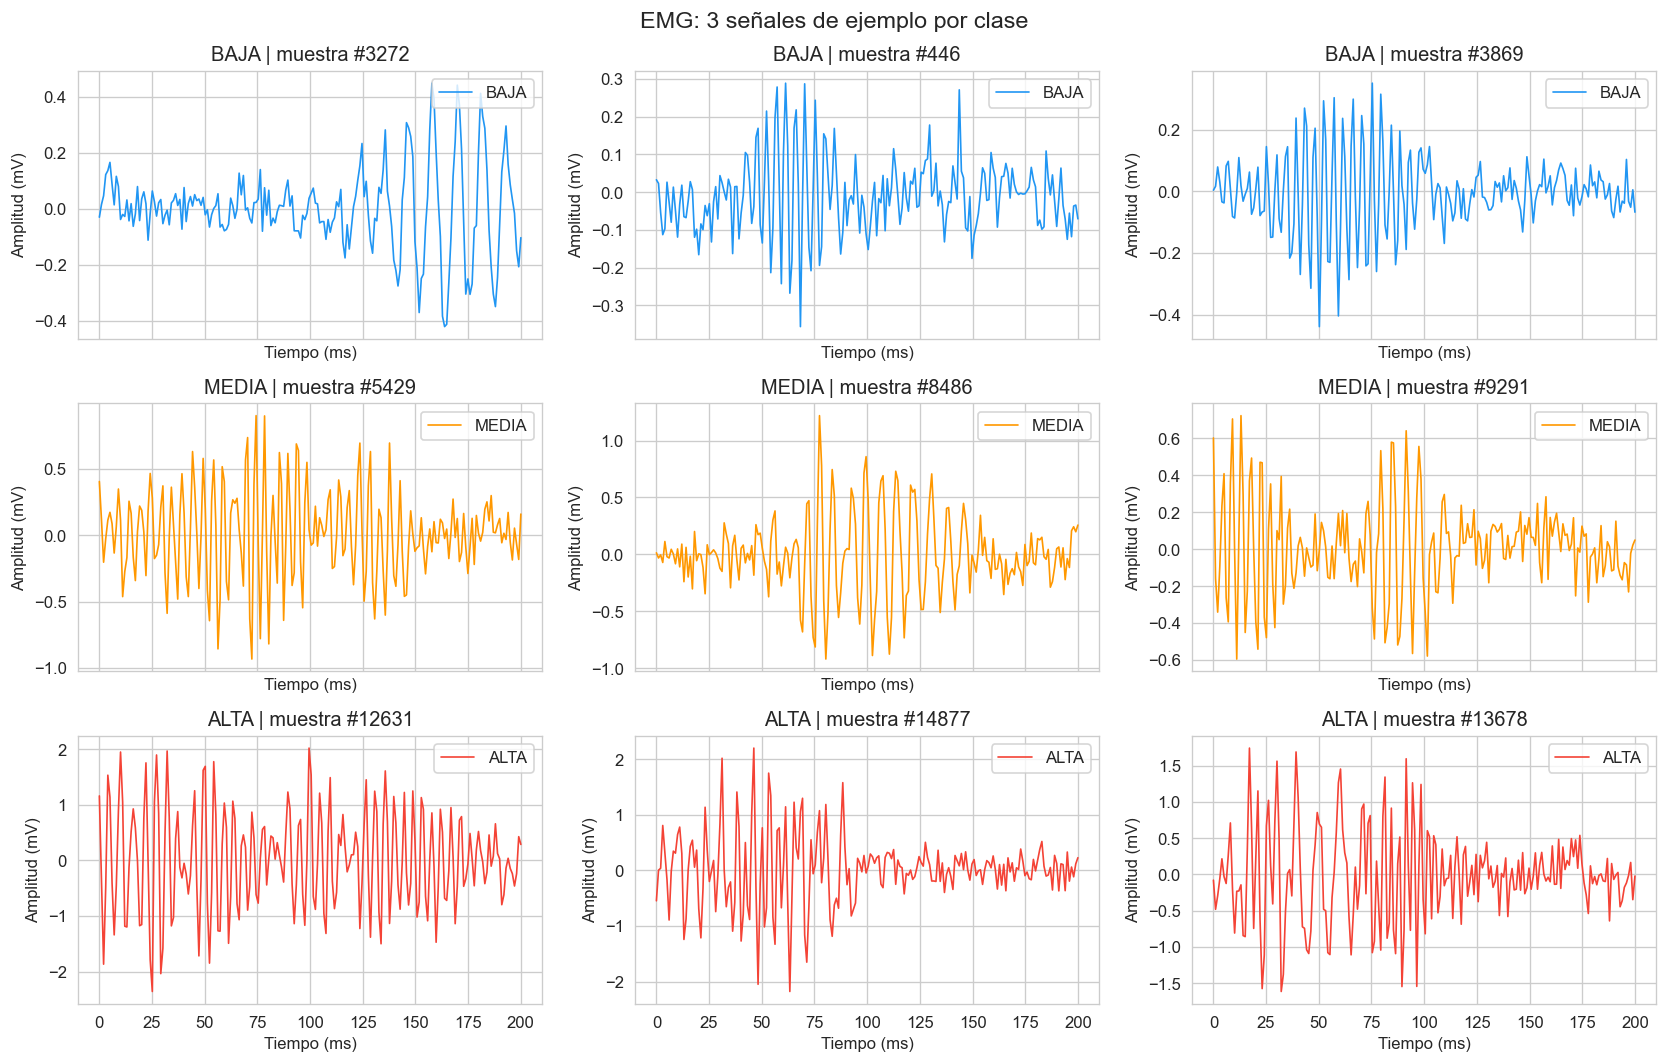

Visualización de señales de muestra completada


In [6]:
rng = np.random.default_rng(RANDOM_SEED)
t_ms = np.linspace(0, 200, N_PUNTOS)

fig, axes = plt.subplots(3, 3, figsize=(14, 9), dpi=120, sharex=True)

for row, clase in enumerate(CLASES):
    idxs = np.where(np.array(labels) == clase)[0]
    chosen = rng.choice(idxs, size=3, replace=False)

    for col, idx in enumerate(chosen):
        ax = axes[row, col]
        ax.plot(t_ms, X[idx], color=COLOR_MAP[clase], linewidth=1.0, label=clase)
        ax.set_title(f'{clase} | muestra #{idx}')
        ax.set_xlabel('Tiempo (ms)')
        ax.set_ylabel('Amplitud (mV)')
        ax.legend(loc='upper right')

plt.suptitle('EMG: 3 señales de ejemplo por clase', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_eda_senales.png', dpi=120)
plt.show()

print('Visualización de señales de muestra completada')


##  EDA — Distribución de Amplitudes
Esperamos mayor activación eléctrica en **ALTA** que en **MEDIA** y **BAJA**. Aquí comparamos amplitud media absoluta, densidades globales y correlación entre puntos temporales iniciales.

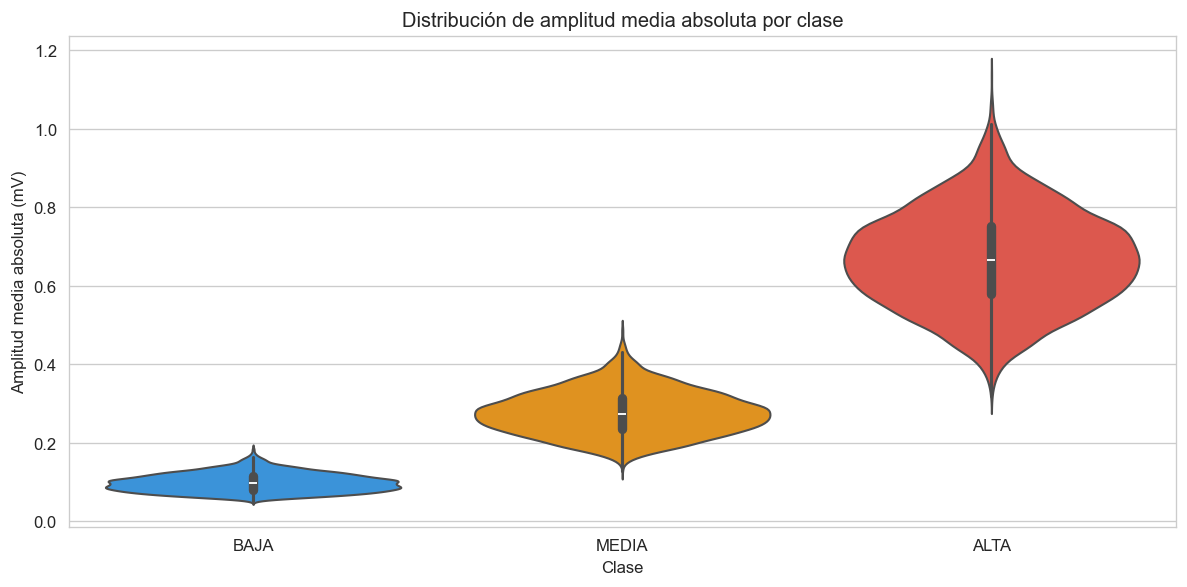

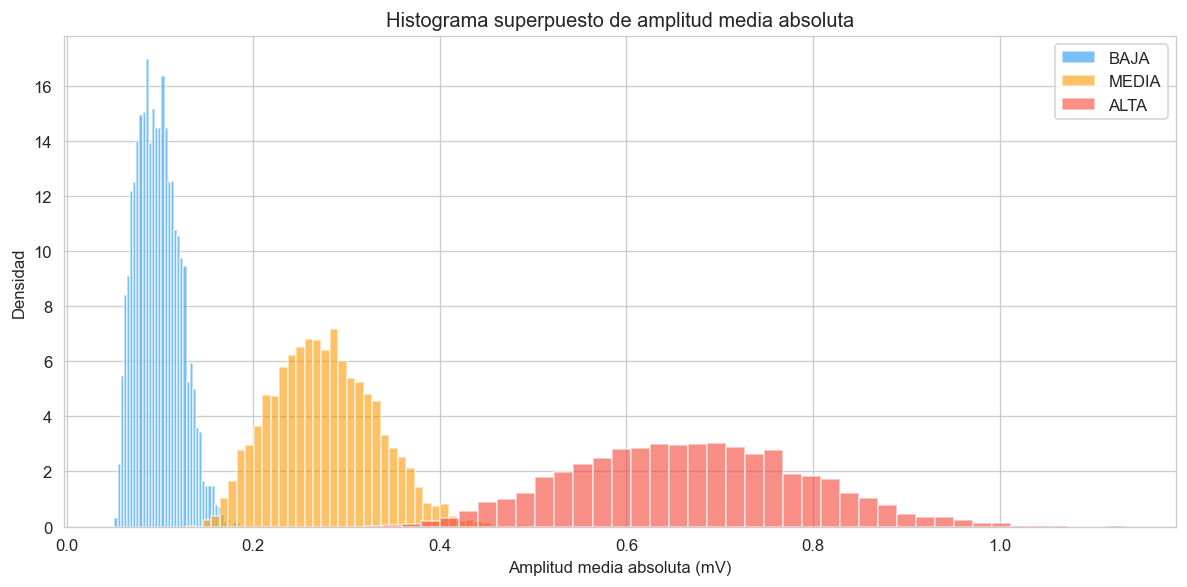

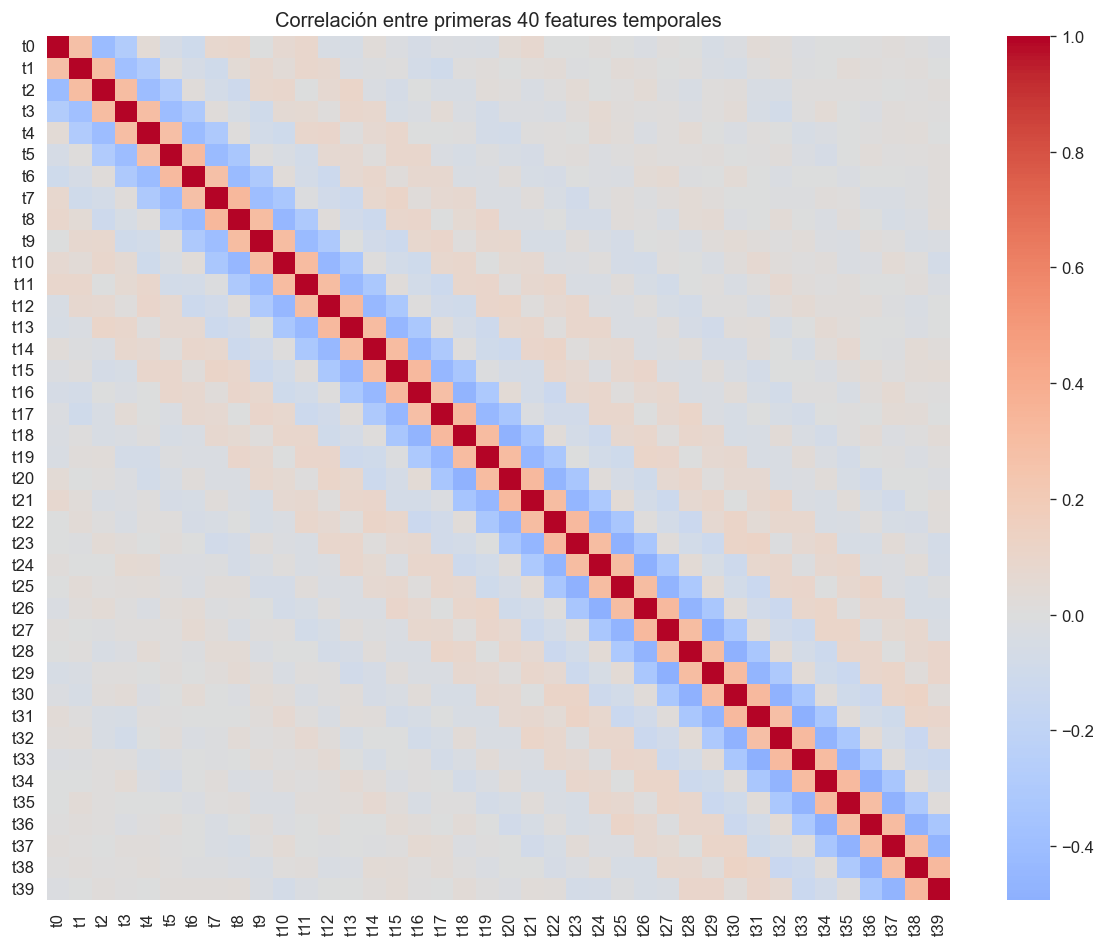

        count      mean       std       min       25%       50%       75%  \
clase                                                                       
ALTA   5000.0  0.667288  0.122624  0.318783  0.578636  0.665510  0.752107   
BAJA   5000.0  0.098457  0.023305  0.051085  0.080170  0.096715  0.114280   
MEDIA  5000.0  0.276553  0.055617  0.127509  0.235840  0.273736  0.314500   

            max  
clase            
ALTA   1.134928  
BAJA   0.185535  
MEDIA  0.491494  


In [7]:
amp_mean_abs = np.mean(np.abs(X), axis=1)
eda_df = pd.DataFrame({'clase': labels, 'amplitud_media_abs': amp_mean_abs})

# Figura 2: violin plot
plt.figure(figsize=(10, 5), dpi=120)
sns.violinplot(data=eda_df, x='clase', y='amplitud_media_abs',
               order=CLASES, palette=COLOR_MAP)
plt.title('Distribución de amplitud media absoluta por clase')
plt.xlabel('Clase')
plt.ylabel('Amplitud media absoluta (mV)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_eda_violin.png', dpi=120)
plt.show()

# Figura 3: histograma superpuesto
plt.figure(figsize=(10, 5), dpi=120)
for clase in CLASES:
    vals = eda_df.loc[eda_df['clase'] == clase, 'amplitud_media_abs']
    plt.hist(vals, bins=40, alpha=0.6, label=clase, color=COLOR_MAP[clase], density=True)
plt.title('Histograma superpuesto de amplitud media absoluta')
plt.xlabel('Amplitud media absoluta (mV)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_eda_hist.png', dpi=120)
plt.show()

# Figura 4: heatmap de correlación (primeras N features temporales)
N_CORR = 40
corr_df = pd.DataFrame(X[:, :N_CORR], columns=[f't{i}' for i in range(N_CORR)])
plt.figure(figsize=(10, 8), dpi=120)
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0)
plt.title(f'Correlación entre primeras {N_CORR} features temporales')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_eda_heatmap.png', dpi=120)
plt.show()

print(eda_df.groupby('clase')['amplitud_media_abs'].describe())


##  Extracción de Features (RMS, MAV, ZCR, WL, VAR)
Calculamos métricas clásicas de EMG para complementar la señal cruda y dar entradas compactas al pipeline de aprendizaje.

In [8]:
def extract_emg_features(signal):
    """
    Extrae features clásicas de EMG para una señal unidimensional.

    Parameters
    ----------
    signal : np.ndarray
        Señal EMG de longitud N_PUNTOS.

    Returns
    -------
    np.ndarray
        Vector de 5 features: [RMS, MAV, ZCR, WL, VAR].
    """
    signal = np.asarray(signal, dtype=np.float32)

    # RMS: potencia efectiva
    rms = np.sqrt(np.mean(signal ** 2))

    # MAV: activación media absoluta
    mav = np.mean(np.abs(signal))

    # ZCR: cruces por cero normalizados por longitud
    zcr = np.mean(np.diff(np.signbit(signal)).astype(np.float32))

    # WL: longitud de onda acumulada
    wl = np.sum(np.abs(np.diff(signal)))

    # VAR: varianza
    var = np.var(signal)

    return np.array([rms, mav, zcr, wl, var], dtype=np.float32)


feature_names = ['RMS', 'MAV', 'ZCR', 'WL', 'VAR']
X_features = np.vstack([extract_emg_features(sig) for sig in X]).astype(np.float32)

feat_df = pd.DataFrame(X_features, columns=feature_names)
feat_df['clase'] = labels

print('Extracción de features completada')
print(f'X_features shape: {X_features.shape}')
display(feat_df.groupby('clase')[feature_names].describe().round(4))

Extracción de features completada
X_features shape: (15000, 5)


RMS                                                             MAV  \
        count    mean     std     min     25%     50%     75%     max   count   
clase                                                                           
ALTA   5000.0  0.8710  0.1505  0.4347  0.7621  0.8681  0.9764  1.6613  5000.0   
BAJA   5000.0  0.1324  0.0292  0.0683  0.1096  0.1313  0.1529  0.2331  5000.0   
MEDIA  5000.0  0.3634  0.0674  0.1619  0.3144  0.3612  0.4101  0.6060  5000.0   

               ...        WL               VAR                          \
         mean  ...       75%       max   count    mean     std     min   
clase          ...                                                       
ALTA   0.6673  ...  176.6264  300.6799  5000.0  0.7808  0.2677  0.1888   
BAJA   0.0985  ...   26.1795   51.2151  5000.0  0.0183  0.0080  0.0047   
MEDIA  0.2766  ...   73.8995  134.7207  5000.0  0.1365  0.0502  0.0262   

                                       
          25%     50%     75%     max  
clase                                  
ALTA   0.5806  0.7532  0.9532  2.7593  
BAJA   0.0120  0.0172  0.0233  0.0543  
MEDIA  0.0988  0.1303  0.1680  0.3673  

[3 rows x 40 columns]

##  Split Train/Val/Test (70/15/15)
Se aplica estratificación para conservar proporciones de clase en todos los subconjuntos.

,train,val,test
BAJA,3500,750,750
MEDIA,3500,750,750
ALTA,3500,750,750


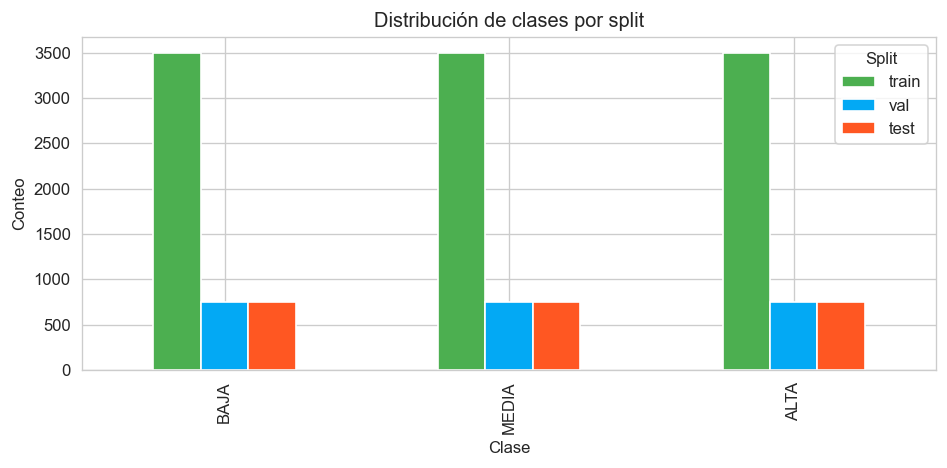

Split estratificado completado 
X_train: (10500, 200), X_val: (2250, 200), X_test: (2250, 200)


In [10]:
indices = np.arange(len(y))

# 1) Separar test (15%)
idx_trainval, idx_test, y_trainval, y_test = train_test_split(
    indices, y,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y
)

# 2) Separar val del resto: 0.15 / 0.85 = 0.176470...
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_trainval, y_trainval,
    test_size=0.1764705882,
    random_state=RANDOM_SEED,
    stratify=y_trainval
)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
X_feat_train, X_feat_val, X_feat_test = X_features[idx_train], X_features[idx_val], X_features[idx_test]

def class_dist(arr):
    s = pd.Series(arr).map(IDX_TO_CLASS)
    return s.value_counts().reindex(CLASES).fillna(0).astype(int)

dist_df = pd.DataFrame({
    'train': class_dist(y_train),
    'val': class_dist(y_val),
    'test': class_dist(y_test)
})
display(dist_df)

ax = dist_df.plot(kind='bar', figsize=(8, 4), color=['#4CAF50', '#03A9F4', '#FF5722'])
ax.get_figure().set_dpi(120)
plt.title('Distribución de clases por split')
plt.xlabel('Clase')
plt.ylabel('Conteo')
plt.legend(title='Split')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_split_dist.png', dpi=120)
plt.show()

print('Split estratificado completado ')
print(f'X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')


##  Normalización (sin leakage)
Ajustamos `StandardScaler` solo con entrenamiento y transformamos validación/test con los parámetros aprendidos. Se guardan dos scalers: señal y features.

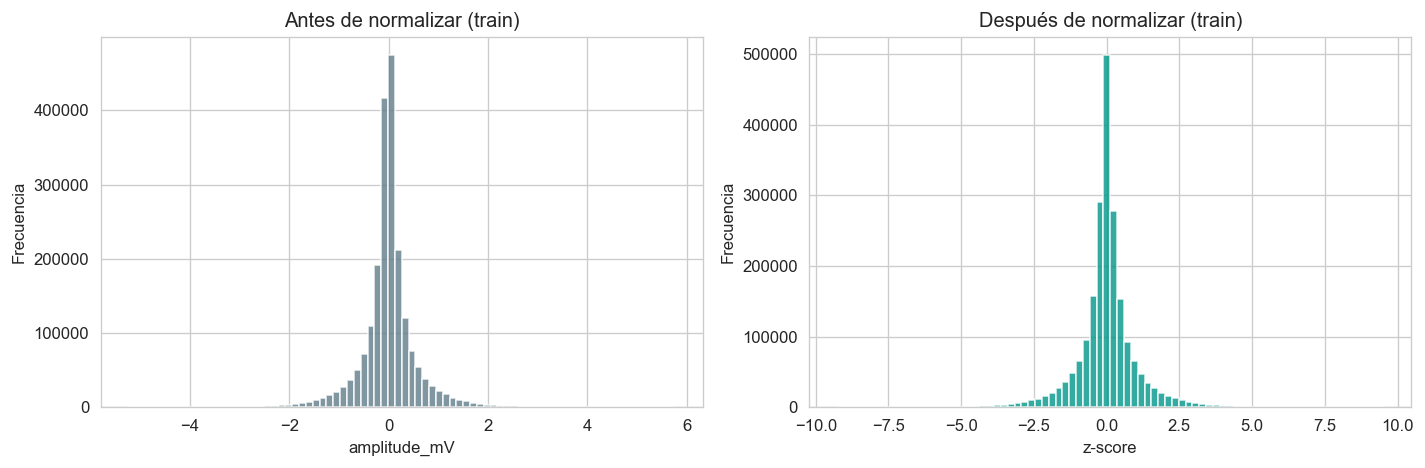

Normalización completada
Media train escalado (aprox): -0.0000
Std train escalado (aprox): 1.0000


In [11]:
# Escalado de señal cruda (200 puntos)
scaler_signal = StandardScaler()
X_train_scaled = scaler_signal.fit_transform(X_train)
X_val_scaled = scaler_signal.transform(X_val)
X_test_scaled = scaler_signal.transform(X_test)

# Escalado de features EMG
scaler_features = StandardScaler()
X_feat_train_scaled = scaler_features.fit_transform(X_feat_train)
X_feat_val_scaled = scaler_features.transform(X_feat_val)
X_feat_test_scaled = scaler_features.transform(X_feat_test)

# Guardar scalers
joblib.dump(scaler_signal, OUTPUT_PATH / 'scaler_signal.pkl')
joblib.dump(scaler_features, OUTPUT_PATH / 'scaler_features.pkl')

# Visualización antes/después
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)
axes[0].hist(X_train.ravel(), bins=80, color='#607D8B', alpha=0.8)
axes[0].set_title('Antes de normalizar (train)')
axes[0].set_xlabel('amplitude_mV')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(X_train_scaled.ravel(), bins=80, color='#009688', alpha=0.8)
axes[1].set_title('Después de normalizar (train)')
axes[1].set_xlabel('z-score')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'EMG_normalizacion.png', dpi=120)
plt.show()

print('Normalización completada')
print(f'Media train escalado (aprox): {X_train_scaled.mean():.4f}')
print(f'Std train escalado (aprox): {X_train_scaled.std():.4f}')


##  Guardado de Arrays
Guardamos matrices y etiquetas listas para entrenamiento del modelo TCN, junto con features clásicas y scalers.

In [12]:
save_items = {
    'X_train.npy': X_train_scaled,
    'X_val.npy': X_val_scaled,
    'X_test.npy': X_test_scaled,
    'y_train.npy': y_train,
    'y_val.npy': y_val,
    'y_test.npy': y_test,
    'X_feat_train.npy': X_feat_train_scaled,
    'X_feat_val.npy': X_feat_val_scaled,
    'X_feat_test.npy': X_feat_test_scaled
}

for filename, arr in save_items.items():
    np.save(OUTPUT_PATH / filename, arr)

save_summary = []
for filename, arr in save_items.items():
    save_summary.append({
        'archivo': filename,
        'shape': tuple(arr.shape),
        'ruta': str((OUTPUT_PATH / filename).relative_to(BASE_PATH))
    })

save_summary.extend([
    {'archivo': 'scaler_signal.pkl', 'shape': '-', 'ruta': str((OUTPUT_PATH / 'scaler_signal.pkl').relative_to(BASE_PATH))},
    {'archivo': 'scaler_features.pkl', 'shape': '-', 'ruta': str((OUTPUT_PATH / 'scaler_features.pkl').relative_to(BASE_PATH))}
])

display(pd.DataFrame(save_summary))
print('Guardado de arrays y scalers completado')

,archivo,shape,ruta
0,X_train.npy,"(10500, 200)",cuadernillos\preprocessed\EMG\X_train.npy
1,X_val.npy,"(2250, 200)",cuadernillos\preprocessed\EMG\X_val.npy
2,X_test.npy,"(2250, 200)",cuadernillos\preprocessed\EMG\X_test.npy
3,y_train.npy,"(10500,)",cuadernillos\preprocessed\EMG\y_train.npy
4,y_val.npy,"(2250,)",cuadernillos\preprocessed\EMG\y_val.npy
5,y_test.npy,"(2250,)",cuadernillos\preprocessed\EMG\y_test.npy
6,X_feat_train.npy,"(10500, 5)",cuadernillos\preprocessed\EMG\X_feat_train.npy
7,X_feat_val.npy,"(2250, 5)",cuadernillos\preprocessed\EMG\X_feat_val.npy
8,X_feat_test.npy,"(2250, 5)",cuadernillos\preprocessed\EMG\X_feat_test.npy
9,scaler_signal.pkl,-,cuadernillos\preprocessed\EMG\scaler_signal.pkl


Guardado de arrays y scalers completado


##  Dashboard Final EMG
Resumen visual del dataset procesado: balance de clases, señal promedio por clase, separación de features y matriz de balance tipo confusión.

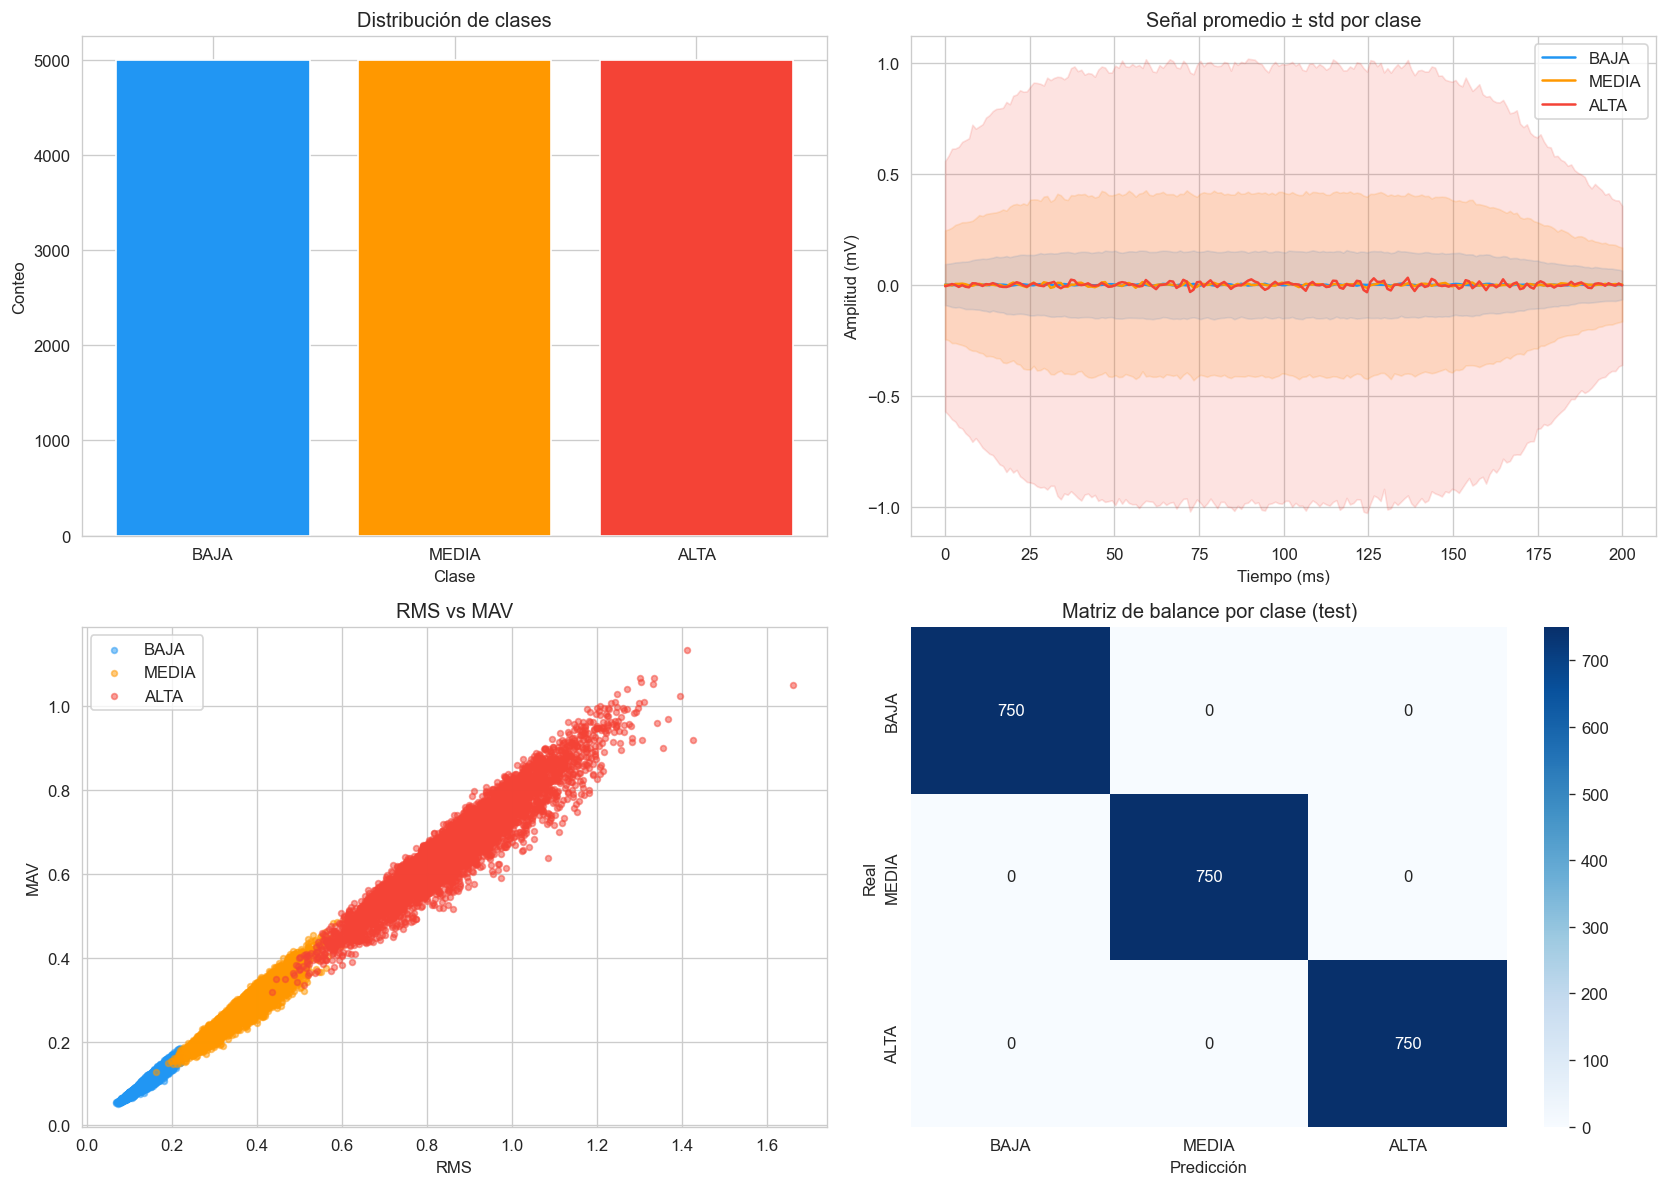

Dashboard final generado
Figura guardada en: C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\figures\EMG_dashboard.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# 1) Distribución de clases
class_counts = pd.Series(y).map(IDX_TO_CLASS).value_counts().reindex(CLASES)
axes[0, 0].bar(class_counts.index, class_counts.values, color=[COLOR_MAP[c] for c in CLASES])
axes[0, 0].set_title('Distribución de clases')
axes[0, 0].set_xlabel('Clase')
axes[0, 0].set_ylabel('Conteo')

# 2) Señal promedio ± std por clase
t_ms = np.linspace(0, 200, N_PUNTOS)
for clase in CLASES:
    idxs = np.where(np.array(labels) == clase)[0]
    mu = X[idxs].mean(axis=0)
    sd = X[idxs].std(axis=0)
    axes[0, 1].plot(t_ms, mu, color=COLOR_MAP[clase], label=clase)
    axes[0, 1].fill_between(t_ms, mu - sd, mu + sd, color=COLOR_MAP[clase], alpha=0.15)
axes[0, 1].set_title('Señal promedio ± std por clase')
axes[0, 1].set_xlabel('Tiempo (ms)')
axes[0, 1].set_ylabel('Amplitud (mV)')
axes[0, 1].legend()

# 3) Scatter RMS vs MAV
feat_plot_df = pd.DataFrame(X_features, columns=feature_names)
feat_plot_df['clase'] = labels
for clase in CLASES:
    sub = feat_plot_df[feat_plot_df['clase'] == clase]
    axes[1, 0].scatter(sub['RMS'], sub['MAV'], s=12, alpha=0.5, color=COLOR_MAP[clase], label=clase)
axes[1, 0].set_title('RMS vs MAV')
axes[1, 0].set_xlabel('RMS')
axes[1, 0].set_ylabel('MAV')
axes[1, 0].legend()

# 4) Matriz de confusión de balance (y_test vs y_test)
cm = confusion_matrix(y_test, y_test, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES, ax=axes[1, 1])
axes[1, 1].set_title('Matriz de balance por clase (test)')
axes[1, 1].set_xlabel('Predicción')
axes[1, 1].set_ylabel('Real')

plt.tight_layout()
dashboard_path = FIGURES_PATH / 'EMG_dashboard.png'
plt.savefig(dashboard_path, dpi=120)
plt.show()

print('Dashboard final generado')
print(f'Figura guardada en: {dashboard_path}')

## Resumen Final

| Elemento | Resultado |
|---|---|
| Total de muestras cargadas | `X.shape[0]` |
| Shape señal cruda | `X.shape` |
| Shape features clásicas | `X_features.shape` |
| Split final | Train 70% / Val 15% / Test 15% |
| Archivos guardados | Señales, etiquetas, features y scalers en `cuadernillos/preprocessed/EMG/` |
| Dashboard | `cuadernillos/figures/EMG_dashboard.png` |

### Próximo paso sugerido
Entrenar la arquitectura **TCN** usando `X_train.npy`, `y_train.npy` y opcionalmente fusionar `X_feat_train.npy` para enriquecer la representación.